### Install prophet

In [1]:
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 493.7 kB/s eta 0:00:24
   - -------------------------------------- 0.5/12.1 MB 493.7 kB/s eta 0:00:24
   -- ------------------------------------- 0.8/12.1 MB 532.8 kB/s eta 0:00:22
   -- ------------------------------------- 0.8/12.1 MB 532.8 kB/s eta 0:00:22
   -- ------------------------------------- 0.8/12.1 MB 532.8 kB/s eta 0:00:22
   --- ------------------------------------ 1.0/12.1 MB 519.1 kB/s eta 0:00:22
   --- ----------------------------

### Import libraries 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

### Load Dataset

In [3]:
df = pd.read_csv("Datasets/fact_orders.csv")

### Convert *order_timestamp* 

In [4]:
df['order_timestamp'] = pd.to_datetime(
    df['order_timestamp'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

### Verify conversion

In [5]:
print(df['order_timestamp'].dtype)
print(df['order_timestamp'].isna().sum())

datetime64[ns]
0


### Create Order Date

In [6]:
df['order_date'] = df['order_timestamp'].dt.date
df['order_date'] = pd.to_datetime(df['order_date'])

### Aggregate Daily Orders

In [7]:
daily_orders = (
    df.groupby('order_date')
      .size()
      .reset_index(name='orders')
)

daily_orders.set_index('order_date', inplace=True)
daily_orders.head()

,orders
order_date,
2025-01-01,774
2025-01-02,770
2025-01-03,776
2025-01-04,713
2025-01-05,753


### Prepare Data for Prophet
Prophet requires:

*ds* → date

*y* → value to forecast

In [8]:
prophet_df = daily_orders.reset_index()
prophet_df.columns = ['ds', 'y']

### Train Prophet Model

In [9]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False
)

model.fit(prophet_df)

18:16:36 - cmdstanpy - INFO - Chain [1] start processing
18:16:38 - cmdstanpy - INFO - Chain [1] done processing


### Forecast Next 30 Days

In [10]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

### View Forecast Output

In [11]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
298,2025-10-26,269.508319,181.569350,352.381782
299,2025-10-27,268.490009,189.845043,350.070003
300,2025-10-28,270.784214,187.428291,361.030904
301,2025-10-29,270.937891,186.334639,351.157519
302,2025-10-30,274.151520,188.151661,356.506278


### Plot Forecast

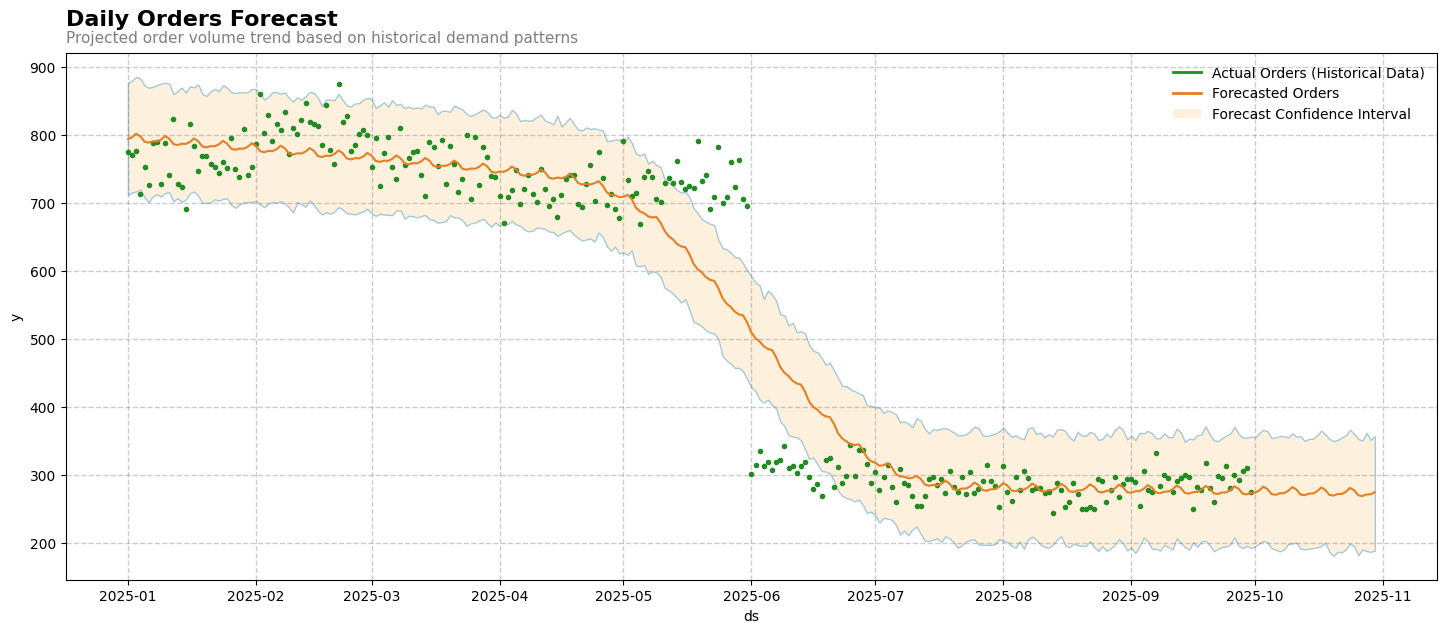

In [26]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Plot forecast
fig = model.plot(forecast)

# Increase figure size
fig.set_size_inches(15, 6)

ax = fig.gca()

# --- CUSTOM COLORS ---
history_color = "#228B22"   # Green
forecast_color = "#E67E22"  # Orange
interval_color = "#FAD7A0"  # Light orange

# Apply colors
ax.lines[0].set_color(history_color)   # Historical data
ax.lines[1].set_color(forecast_color)  # Forecast line
ax.collections[0].set_facecolor(interval_color)
ax.collections[0].set_alpha(0.35)

# Title
ax.set_title(
    "Daily Orders Forecast",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=20
)

# Subtitle (below title, left aligned)
ax.text(
    0,
    1.02,
    "Projected order volume trend based on historical demand patterns",
    transform=ax.transAxes,
    fontsize=11,
    color="gray",
    ha="left"
)

# Grid
ax.grid(True, linestyle="--", alpha=0.4)

# --- LEGEND ---
legend_elements = [
    Line2D([0], [0], color=history_color, lw=2, label="Actual Orders (Historical Data)"),
    Line2D([0], [0], color=forecast_color, lw=2, label="Forecasted Orders"),
    Patch(facecolor=interval_color, alpha=0.35, label="Forecast Confidence Interval")
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=False
)

plt.show()

### Save Figure

In [30]:
fig.savefig("Figure/daily_orders_forecast.png", dpi=300, bbox_inches="tight")